# AM10 - Module: Intermediate

## Lecture 12


### Learning objectives:
Higher dimensions: two-dimensional random walks and diffusion.

In [1]:
import numpy as np
import random as rd
import matplotlib.pyplot as plt
import time

### A drunken sailor in one dimension

 Introduce ideas of walker, random movement in one dimension, 
 plots as a function of time,
 average should be zero! (but need many tries or samples)

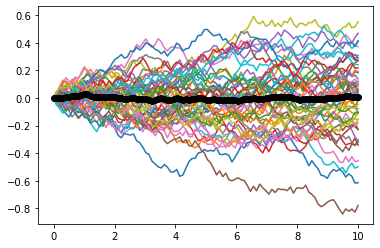

In [11]:
tmax=10
dt=0.1
num_times=int(tmax/dt)

time=np.linspace(0,tmax,num_times)
r=np.zeros(num_times)

rbias=0.50

Nsailors=50
rav=np.zeros(num_times)

for ns in range(Nsailors):

    for n in range(1,num_times):
        r[n]=r[n-1]+(np.random.rand()-rbias)*dt
        rav[n]=rav[n]+r[n]
    
    plt.plot(time,r)
    
rav=rav/Nsailors

plt.plot(time,rav,'ko-',linewidth='1.5')
plt.show()

## Two-dimensional random walks and diffusion

In two dimensions, the diffusion equation is:
$$\frac{\partial f}{\partial t} = 
D_x \frac{\partial^2 f}{\partial x^2} + D_y \frac{\partial^2 f}{\partial y^2}$$
and its solution is:
$$f(x,y) = (A_x \; e^{-(x-x_0)^2/2 \sigma_x^2})  (A_y \; e^{-(y-y_0)^2/2 \sigma_y^2})$$
with:
$$ \sigma_x^2 = 2D_x t, \; \; \; \; \;  \sigma_y^2 = 2 D_y t$$

We can simulate this behavior by two-dimensional random walks from which we determine the value of the diffusion constant in different directions, $D_x, D_y$.

In [35]:
#
# Initialize parameters
#
Deltat=200               # total time duration

Nwalk=5000                # Number of walkers

deltx=1                # step in x direction
delty=1                # step in y direction

In [36]:
#
#  from the defined parameters obtain steps and range
#
delt=np.sqrt(deltx**2+delty**2)                # distance for each step
DRX=np.sqrt(Deltat*deltx)   # range of walkers that can be reached during this time
DRY=np.sqrt(Deltat*delty)   # range of walkers that can be reached during this time
DR=max(DRX,DRY)
#
#  here we define an ELLIPSE of size equal to the average square displacement
#  to be calculated during the simulation
#
Npidiv=40
theta=np.linspace(0,2*np.pi,Npidiv)
xel=np.zeros(Npidiv)
yel=np.zeros(Npidiv)
#
# initialize arrays
#
xpos=np.zeros(Nwalk)
ypos=np.zeros(Nwalk)
rdist=np.zeros(Deltat)
times=np.zeros(Deltat)
xav=np.zeros(Deltat)
yav=np.zeros(Deltat)
x2av=np.zeros(Deltat)
y2av=np.zeros(Deltat)

In [37]:
#
# run the simulation for total time Deltat
#

for t in range (Deltat):
    times[t]=t
    xpos=xpos+deltx*(np.random.rand(Nwalk)-0.5)
    ypos=ypos+delty*(np.random.rand(Nwalk)-0.5)
    xav[t]=np.mean(xpos)
    yav[t]=np.mean(ypos)
    x2av[t]=np.mean(xpos**2)
    y2av[t]=np.mean(ypos**2)
    rdist[t]=(np.sum(xpos**2)+np.sum(ypos**2))/Nwalk
    xel=deltx*np.sqrt(rdist[t-1])*np.cos(theta)
    yel=delty*np.sqrt(rdist[t-1])*np.sin(theta)



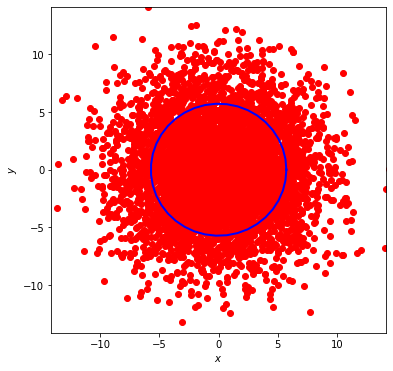

In [38]:
#
#  plot the actual positions of walkers on the 2D plane
#
fig=plt.figure(figsize=(6,6))
plt.plot(xpos,ypos,'ro',lw=2)
plt.plot(xel,yel,'b-',lw=2)
plt.xlim(-DR,DR)
plt.ylim(-DR,DR)
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.show()


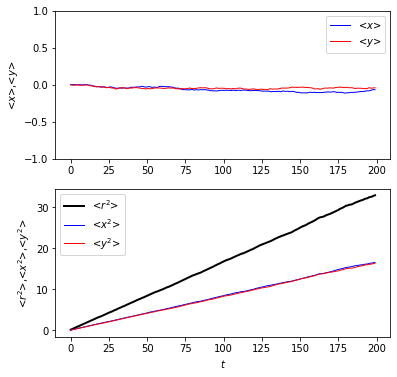

In [39]:
#
# plot the average x and y positions of all walkers,
#  and the mean square displacement, as functions of time
#
fig=plt.figure(1,figsize=(6,6))
plt.subplot(2,1,1)
plt.plot(times,xav,color='blue',lw=1,label='<$x$>')
plt.plot(times,yav,color='red',lw=1,label='<$y$>')
plt.ylabel('<$x$>,<$y$>')
plt.ylim(-1.0,1.0)
plt.legend()

plt.subplot(2,1,2)
plt.plot(times,rdist,'k',lw=2,label='<$r^2$>')
plt.plot(times,x2av,'b',lw=1,label='<$x^2$>')
plt.plot(times,y2av,'r',lw=1,label='<$y^2$>')
plt.xlabel('$t$')
plt.ylabel('<$r^2$>,<$x^2$>,<$y^2$>')
plt.legend()
plt.show()


In [40]:
#
#  a small subroutine to bin the positions of the walkers
#
def get_bin_mean(N,arr, b_start, b_end):
    n_bin=0
    for nb in range(N):
        if(arr[nb]>=b_start):
            if(arr[nb]<b_end):
                n_bin=n_bin+1
    return n_bin

In [41]:
Nbins=50
bins = np.linspace(-DR,DR,Nbins)
x_binned = np.zeros(Nbins)
y_binned = np.zeros(Nbins)

for n in range(Nbins-1):
    x_binned[n]=get_bin_mean(Nwalk,xpos, bins[n], bins[n+1])
    y_binned[n]=get_bin_mean(Nwalk,ypos, bins[n], bins[n+1])

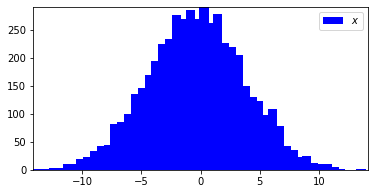

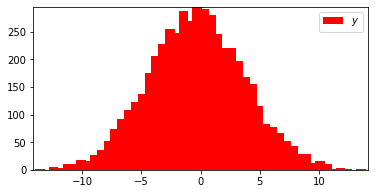

In [42]:
#
#  plot the binned (x,y) positions of walkers
#
x_max=np.max(x_binned)
x_val=bins
y_max=np.max(y_binned)
y_val=bins
fig=plt.figure(figsize=(6,3))
plt.bar(x_val,x_binned,color='blue',label='$x$')
plt.xlim(-DR,DR)
plt.ylim(0,x_max+0.01)
plt.legend()
plt.show()

fig=plt.figure(figsize=(6,3))
plt.bar(y_val,y_binned,color='red',label='$y$')
plt.xlim(-DR,DR)
plt.ylim(0,y_max+0.01)
plt.legend()
plt.show()


### Extracting the diffusion coefficient

From the general expression:
$$ f(x) = A_x \; e^{-(x-x_0)^2/4Dt} = A_x \; e^{-(x-x_0)^2/2\sigma_x^2}$$
we want to fit gaussian functions to the above distributions, and extract the standard deviation which will give us the diffusion constant
$$ \sigma_x^2 = 2Dt \Rightarrow D = \frac{\sigma_x^2}{2t}$$

Notice that the results are NOT normalized gaussians, so we need to take into consideration this feature before we do any fitting.

We will use the "curve_fit" routine to do the fitting, to which we need to supply the proper function with the parameters that we want to obtain from the fit.


  -0.35    4.07
  -0.38   -4.03


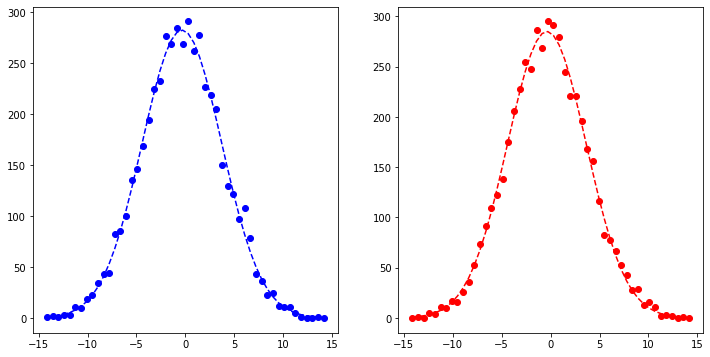

In [43]:
from scipy.optimize import curve_fit

def gauss_nonor(x,x0,sigma,A):
    
    '''Not normalized gaussian function'''
    #---------------------------------------------
    func=A*np.exp(-(x-x0)**2/(2*sigma**2))
    #---------------------------------------------

    return func

Nx=np.sum(x_binned)
poptx, pcovx = curve_fit(gauss_nonor, x_val, x_binned)
print(' %6.2f' %poptx[0], ' %6.2f' %poptx[1])
x_fit=gauss_nonor(bins,poptx[0],poptx[1],poptx[2])

popty, pcovy = curve_fit(gauss_nonor, y_val, y_binned)
print(' %6.2f' %popty[0],' %6.2f' %popty[1])
y_fit=gauss_nonor(bins,popty[0],popty[1],popty[2])


fig=plt.figure(1,figsize=(12,6))
plt.subplot(1,2,1)
plt.plot(x_val,x_binned,'bo')
plt.plot(x_val,x_fit,'b--')
plt.subplot(1,2,2)
plt.plot(y_val,y_binned,'ro')
plt.plot(y_val,y_fit,'r--')
plt.show()


#### Check the results of fitting: calculate parameters of gaussian distributions:

Mean:
$$ x_0 = \int_{-\infty}^{\infty} x \; g_{\sigma}(x) \; dx \Rightarrow 
 x_m = \frac{1}{N} \sum_{i=1}^N x_i f_i $$

Standard deviation:
$$ \sigma^2 = \int_{-\infty}^{\infty} (x-x_0)^2 \; g_{\sigma}(x) \; dx 
\Rightarrow
\sigma_x = \left [ \frac{1}{N} \sum_{i=1}^N (x_i-x_m)^2 f_i \right]^{1/2}$$

In [44]:
x_norm=np.sum(x_binned)
x_mean=np.sum(x_val*x_binned)/x_norm
x_std=np.sqrt(np.sum((x_val-x_mean)**2*x_binned)/x_norm)
print(' %6.2f' %x_mean,' %6.2f' %x_std, ' %10.2f' %x_norm)
print(' %6.2f' %poptx[0], ' %6.2f' %poptx[1])

print()

y_norm=np.sum(y_binned)
y_mean=np.sum(y_val*y_binned)/y_norm
y_std=np.sqrt(np.sum((y_val-y_mean)**2*y_binned)/y_norm)
print(' %6.2f' %y_mean, ' %6.2f' %y_std, ' %10.2f' %y_norm)
print(' %6.2f' %popty[0],' %6.2f' %popty[1])

  -0.36    4.06     4998.00
  -0.35    4.07

  -0.33    4.05     5000.00
  -0.38   -4.03
